# Module 1 — Pricing Engine

Comparative analysis: **Black-Scholes (analytical)** vs **Monte Carlo** for European options.  
Greeks (Delta, Gamma, Vega, Theta) and the log-normal distribution of $S_T$.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import matplotlib.pyplot as plt
from black_scholes import bs_call_price, bs_put_price, bs_greeks
from monte_carlo import mc_call_price

S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.20, 1.0
np.random.seed(42)
print("OK")

OK


## 1. Call price vs Strike — Black-Scholes vs Monte Carlo

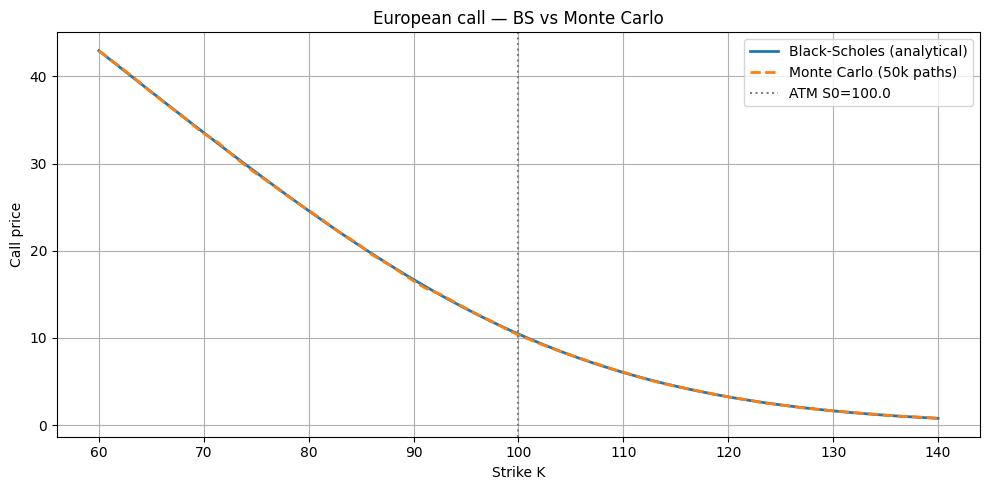

ATM  BS=10.4506  MC=10.4173  error=0.0332


In [2]:
strikes = np.linspace(60, 140, 50)
bs_prices = [bs_call_price(S0, Ki, r, sigma, T) for Ki in strikes]
mc_prices = [mc_call_price(S0, Ki, r, sigma, T, 50_000) for Ki in strikes]

plt.figure(figsize=(10, 5))
plt.plot(strikes, bs_prices, lw=2, label="Black-Scholes (analytical)")
plt.plot(strikes, mc_prices, lw=2, ls="--", label="Monte Carlo (50k paths)")
plt.axvline(S0, color="gray", ls=":", label=f"ATM S0={S0}")
plt.xlabel("Strike K"); plt.ylabel("Call price")
plt.title("European call — BS vs Monte Carlo")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

bs_atm = bs_call_price(S0, K, r, sigma, T)
mc_atm = mc_call_price(S0, K, r, sigma, T, 100_000)
print(f"ATM  BS={bs_atm:.4f}  MC={mc_atm:.4f}  error={abs(bs_atm - mc_atm):.4f}")

## 2. Greeks vs Spot Price

`bs_greeks(S, K, r, sigma, T)` returns a **dict** with keys:  
`delta_call`, `delta_put`, `gamma`, `vega`, `theta_call`, `theta_put`.

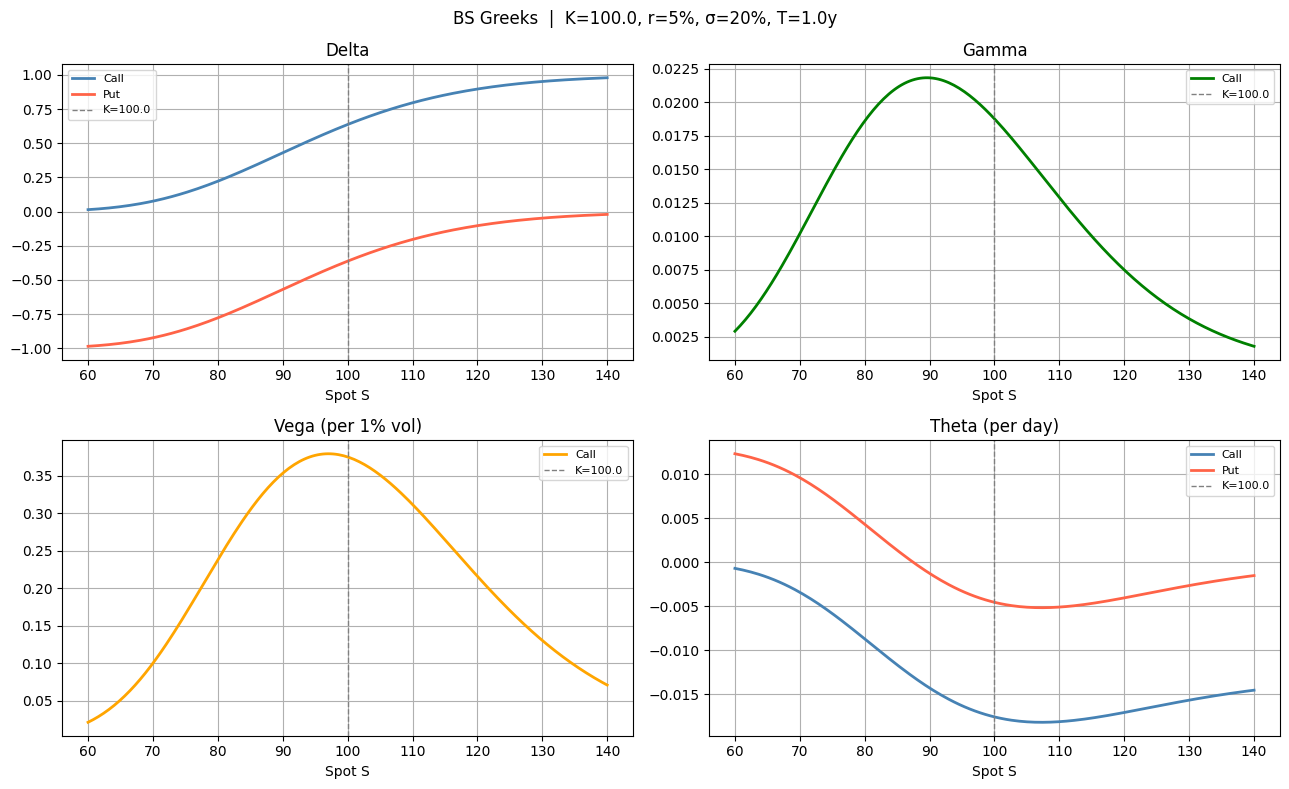

In [3]:
spots = np.linspace(60, 140, 200)
dc, dp, gm, vg, tc, tp = [], [], [], [], [], []

for S in spots:
    g = bs_greeks(S, K, r, sigma, T)   # returns a dict
    dc.append(g["delta_call"]); dp.append(g["delta_put"])
    gm.append(g["gamma"]);      vg.append(g["vega"])
    tc.append(g["theta_call"]); tp.append(g["theta_put"])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
titles = ["Delta", "Gamma", "Vega (per 1% vol)", "Theta (per day)"]
series = [(dc, dp), (gm, None), (vg, None), (tc, tp)]
colors = [("steelblue", "tomato"), ("green", None), ("orange", None), ("steelblue", "tomato")]

for ax, title, (s1, s2), (c1, c2) in zip(axes.flat, titles, series, colors):
    ax.plot(spots, s1, color=c1, lw=2, label="Call")
    if s2 is not None:
        ax.plot(spots, s2, color=c2, lw=2, label="Put")
    ax.axvline(K, color="gray", lw=1, ls="--", label=f"K={K}")
    ax.set_title(title); ax.set_xlabel("Spot S")
    ax.legend(fontsize=8); ax.grid(True)

fig.suptitle(f"BS Greeks  |  K={K}, r={r*100:.0f}%, σ={sigma*100:.0f}%, T={T}y", fontsize=12)
plt.tight_layout(); plt.show()

## 3. Log-normal distribution of $S_T$

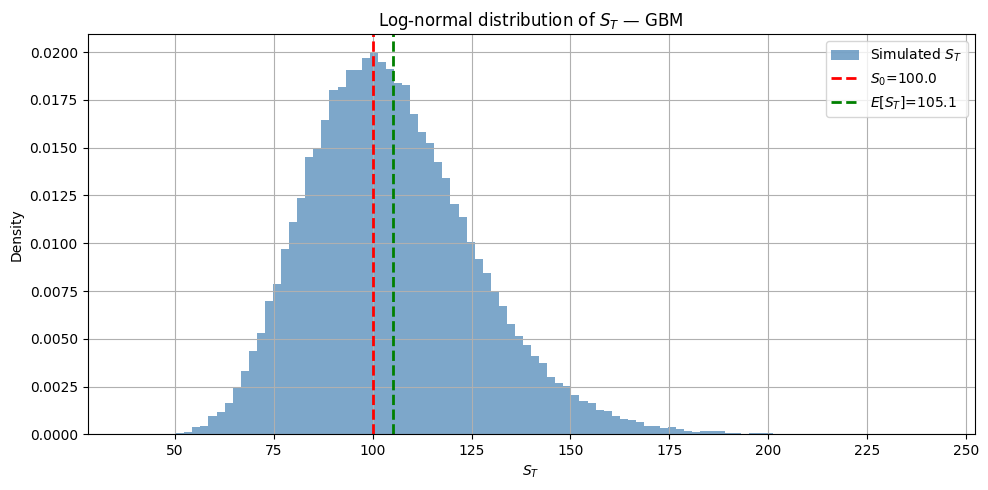

E[S_T]    = 105.09  (theoretical: 105.13)
Median    = 103.07


In [4]:
Z  = np.random.standard_normal(100_000)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

plt.figure(figsize=(10, 5))
plt.hist(ST, bins=100, density=True, alpha=0.7, color="steelblue", label="Simulated $S_T$")
plt.axvline(S0,          color="red",   lw=2, ls="--", label=f"$S_0$={S0}")
plt.axvline(np.mean(ST), color="green", lw=2, ls="--", label=f"$E[S_T]$={np.mean(ST):.1f}")
plt.xlabel("$S_T$"); plt.ylabel("Density")
plt.title("Log-normal distribution of $S_T$ — GBM")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print(f"E[S_T]    = {np.mean(ST):.2f}  (theoretical: {S0*np.exp(r*T):.2f})")
print(f"Median    = {np.median(ST):.2f}")

## 4. Put-Call Parity verification

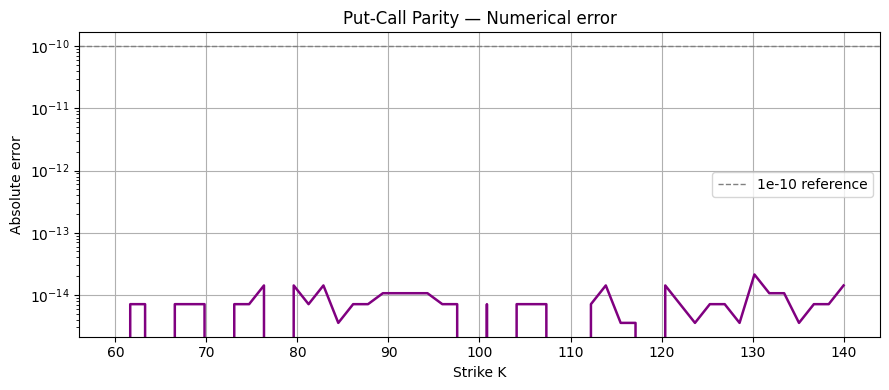

Max parity error: 2.13e-14


In [5]:
errors = [
    abs(bs_call_price(S0, Ki, r, sigma, T)
        - bs_put_price(S0, Ki, r, sigma, T)
        - (S0 - Ki * np.exp(-r * T)))
    for Ki in strikes
]
plt.figure(figsize=(9, 4))
plt.semilogy(strikes, errors, color="purple", lw=1.8)
plt.axhline(1e-10, color="gray", lw=1, ls="--", label="1e-10 reference")
plt.xlabel("Strike K"); plt.ylabel("Absolute error")
plt.title("Put-Call Parity — Numerical error")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
print(f"Max parity error: {max(errors):.2e}")